# Proyecto 1 - Monitoreo Transaccional
### Detectar lo que el orden revela

**Universidad del Valle - Deep Learning 2026**

Este notebook cubre la parte de **Persona 1** del equipo:

1. Generación de datos sintéticos e integridad de datos.
2. Partición temporal train / validación / test.
3. Preparación de variables para el Modelo A.
4. **Modelo A:** línea base sin orden.
5. Análisis económico preliminar realizado únicamente en validación.

Las secciones de **Modelo B**, **Apuesta C**, las **pruebas de falsificación** y la
**evaluación final única sobre test** serán agregadas posteriormente en este mismo
notebook, usando exactamente el mismo dataset, partición y horizonte de predicción.

> **Protocolo de test sellado:** `seed=42` se considera una ejecución piloto y se
> descarta para la evaluación final. Esta versión utiliza `seed=2027`. Durante el
> desarrollo solamente se observan train y validación. No se calculan predicciones,
> métricas, gráficas, umbrales ni costos sobre test. Test se evaluará una sola vez,
> después de congelar A, B, C y todas las decisiones experimentales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix)
from sklearn.ensemble import HistGradientBoostingClassifier

import generador  # módulo reproducible incluido como generador.py

pd.set_option("display.max_columns", 20)
np.random.seed(2027)

## 1. Generación de datos sintéticos e integridad de datos

**Por qué usamos datos sintéticos:** elegimos la Ruta A porque permite controlar qué
patrones dependen del orden y documentar esa dependencia con precisión, algo difícil de
garantizar con un conjunto real sin etiquetas del mecanismo de fraude.

**Cómo se generan los datos:**

- `N` clientes con perfiles heterogéneos: frecuencia diaria de transacciones (Gamma),
  monto típico (lognormal por cliente), comercios preferidos y canal preferido.
- Transacciones legítimas simuladas como un proceso de llegadas por día (Poisson).
- Tres mecanismos de fraude inyectados en un subconjunto de clientes.
- Una semilla fija (`seed=2027`) hace que el dataset sea reproducible.

### Los tres tipos de fraude

| Tipo | Patrón | ¿Depende del orden? |
|---|---|---|
| `escalada` | 3-5 compras pequeñas seguidas de una compra grande, dentro de una ventana corta. | **Sí, principalmente.** Al barajar la secuencia desaparece el patrón pequeño-pequeño-grande, aunque se conservan los eventos. |
| `rafaga` | 8-12 transacciones en 30-45 minutos, con montos moderados y comercios variados. | No principalmente. La señal está en el conteo dentro de la ventana y puede ser capturada por agregados. |
| `comercio_atipico` | Una transacción grande, en horario inusual y en un comercio nunca usado previamente por ese cliente. | No depende del orden. Esperamos que A tenga dificultad porque no recibe una variable que indique si el comercio es nuevo para ese cliente. |

### Caso de fallo esperado, declarado antes del entrenamiento

Antes de entrenar, esperamos que el Modelo A tenga su peor desempeño en
`comercio_atipico`. `FEATURES_A` solamente incluye frecuencia **global** del comercio y
diversidad de comercios durante siete días; ninguna variable indica causalmente si ese
cliente específico había usado antes ese comercio. El horario tampoco debería bastar,
porque las transacciones legítimas pueden ocurrir a cualquier hora.

Esta expectativa se confirma o refuta usando **validación**, nunca test.

### Variables agregadas causales

Para cada transacción, el generador calcula usando exclusivamente el historial anterior
del mismo cliente:

- `monto_prom_24h`
- `n_trans_ultima_hora`
- `monto_max_dia`
- `diversidad_comercios_7d`

El código completo y comentado está en `generador.py`.

In [2]:
cfg = generador.Config(
    n_clientes=3000,
    periodo_dias=180,
    tasa_fraude_clientes=0.08,
    seed=2027,
)
df = generador.generar_dataset(cfg)

# Durante el desarrollo no se inspeccionan las etiquetas de test.
df_desarrollo = df.loc[df.dia < 150]

print("Tamaño total del dataset:", df.shape)
print("Clientes:", df["client_id"].nunique())
print("Tasa de fraude en train + validación:", round(df_desarrollo["label"].mean(), 5))
print()
print("Mecanismos en train + validación:")
print(df_desarrollo["fraud_type"].value_counts())
df.head()

Tamaño total del dataset: (407524, 16)
Clientes: 3000
Tasa de fraude en train + validación: 0.00318

Mecanismos en train + validación:
fraud_type
legitimo            338304
rafaga                 583
escalada               439
comercio_atipico        58
Name: count, dtype: int64


,transaction_id,client_id,seq_index,dia,timestamp,amount,merchant,merchant_name,channel,channel_name,monto_prom_24h,n_trans_ultima_hora,monto_max_dia,diversidad_comercios_7d,fraud_type,label
0,0,0,0,0,11.885029,39.580858,6,streaming,1,online,0.000000,0.0,0.000000,0.0,legitimo,0
1,1,0,1,2,49.127790,56.358697,17,electrodomesticos,1,online,0.000000,0.0,0.000000,1.0,legitimo,0
2,2,0,2,4,105.737331,27.352933,14,mascotas,1,online,0.000000,0.0,0.000000,2.0,legitimo,0
3,3,0,3,4,107.972145,80.939783,14,mascotas,1,online,27.352933,0.0,27.352933,3.0,legitimo,0
4,4,0,4,6,158.316809,79.397844,14,mascotas,1,online,0.000000,0.0,0.000000,3.0,legitimo,0


**Reproducibilidad:** volver a ejecutar
el generador con la misma configuración y `seed=2027` produce exactamente el mismo
dataset. La semilla forma parte de la configuración que debe conservarse junto con los
artefactos.

## 2. Partición temporal

Usamos el día de simulación como eje temporal; no se realiza una partición aleatoria.

- **Train:** días 0-119.
- **Validación:** días 120-149.
- **Test sellado:** días 150-179.

Controles contra fuga de información:

- Las variables agregadas son causales y nunca observan transacciones futuras.
- Las frecuencias y cualquier transformación aprendida se ajustan solamente con train.
- Validación se usa para arquitectura, hiperparámetros, hipótesis y umbral.
- Durante el desarrollo no se inspeccionan etiquetas ni resultados de test.

In [3]:
df["dia_semana"] = df["dia"] % 7
df["hora_del_dia"] = df["timestamp"] % 24
df["split"] = np.where(
    df.dia < 120,
    "train",
    np.where(df.dia < 150, "val", "test"),
)

# Se muestran únicamente tamaños y rangos temporales, sin estadísticas de las
# etiquetas de test.
resumen_temporal = df.groupby("split").agg(
    n_transacciones=("transaction_id", "size"),
    primer_dia=("dia", "min"),
    ultimo_dia=("dia", "max"),
)

resumen_desarrollo = (
    df.loc[df.split.isin(["train", "val"])]
      .groupby("split")
      .agg(
          n_transacciones=("label", "size"),
          tasa_fraude=("label", "mean"),
          n_fraudes=("label", "sum"),
      )
)

print("Partición temporal (test sin inspeccionar):")
display(resumen_temporal)
print("Etiquetas observadas solamente en desarrollo:")
display(resumen_desarrollo)

Partición temporal (test sin inspeccionar):


,n_transacciones,primer_dia,ultimo_dia
split,,,
test,68140,150,179
train,271752,0,119
val,67632,120,149


Etiquetas observadas solamente en desarrollo:


,n_transacciones,tasa_fraude,n_fraudes
split,,,
train,271752,0.002999,815
val,67632,0.003918,265


## 3. Preparación de variables para el Modelo A

El Modelo A no lee una secuencia. Recibe variables agregadas y atributos de la
transacción actual. Las frecuencias de comercio y canal se ajustan exclusivamente con
train y se aplican sin cambios a validación y test.

In [4]:
train_mask = df.split == "train"
freq_comercio = df.loc[train_mask].groupby("merchant").size() / train_mask.sum()
freq_canal = df.loc[train_mask].groupby("channel").size() / train_mask.sum()

df["merchant_freq"] = df["merchant"].map(freq_comercio).fillna(0.0)
df["channel_freq"] = df["channel"].map(freq_canal).fillna(0.0)

FEATURES_A = [
    "amount",
    "monto_prom_24h",
    "n_trans_ultima_hora",
    "monto_max_dia",
    "diversidad_comercios_7d",
    "merchant_freq",
    "channel_freq",
    "hora_del_dia",
    "dia_semana",
]

Xtr = df.loc[df.split == "train", FEATURES_A]
ytr = df.loc[df.split == "train", "label"]
Xval = df.loc[df.split == "val", FEATURES_A]
yval = df.loc[df.split == "val", "label"]

# Xte puede prepararse sin examinar sus etiquetas; yte se creará únicamente en la
# evaluación final, cuando A, B y C estén congelados.
Xte = df.loc[df.split == "test", FEATURES_A]

print("Variables del Modelo A:", FEATURES_A)
print("Train:", Xtr.shape, " Validación:", Xval.shape, " Test sellado:", Xte.shape)

Variables del Modelo A: ['amount', 'monto_prom_24h', 'n_trans_ultima_hora', 'monto_max_dia', 'diversidad_comercios_7d', 'merchant_freq', 'channel_freq', 'hora_del_dia', 'dia_semana']
Train: (271752, 9)  Validación: (67632, 9)  Test sellado: (68140, 9)


## 4. Modelo A - Línea base sin orden

Usamos gradient boosting de árboles (`HistGradientBoostingClassifier`) sobre variables
agregadas. `class_weight="balanced"` compensa el desbalance y **AUC-PR** es la métrica
principal. No usamos exactitud como métrica principal porque un clasificador que nunca
detectara fraude tendría cerca de 99.7 % de exactitud y sería inútil.

Esta implementación pertenece a scikit-learn y evita depender de instalaciones externas
durante la reproducción del notebook.

In [5]:
modelo_a = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=4,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=cfg.seed,
)
modelo_a.fit(Xtr, ytr)

puntaje_val = modelo_a.predict_proba(Xval)[:, 1]
print("AUC-PR (validación):", round(average_precision_score(yval, puntaje_val), 4))

AUC-PR (validación): 0.7281


### Desempeño por mecanismo, calculado en validación

Este diagnóstico permite formular las hipótesis de B y C sin consultar test. Todos los
mecanismos se comparan contra el mismo conjunto de transacciones legítimas de
validación.

In [6]:
df_val = df.loc[df.split == "val"].copy()
df_val["puntaje_a"] = puntaje_val

filas = []
for tipo in ["escalada", "rafaga", "comercio_atipico"]:
    mask = (df_val.fraud_type == tipo) | (df_val.label == 0)
    sub = df_val.loc[mask]
    if sub.label.sum() > 0:
        filas.append({
            "fraud_type": tipo,
            "n_positivos_val": int(sub.label.sum()),
            "AUC-PR_Modelo_A_val": average_precision_score(
                sub.label, sub.puntaje_a
            ),
        })

resumen_tipo_val = pd.DataFrame(filas)
resumen_tipo_val

,fraud_type,n_positivos_val,AUC-PR_Modelo_A_val
0,escalada,130,0.657383
1,rafaga,126,0.722595
2,comercio_atipico,9,0.015441


**Lectura basada únicamente en
validación:** A debería ser más fuerte en `rafaga`, porque recibe el conteo de la última
hora; debería ser más débil en `escalada`, que fue diseñada para depender del orden; y
esperamos su peor desempeño en `comercio_atipico`, porque no recibe una señal de novedad
específica por cliente.

Para B, la hipótesis que debe intentar refutarse es que su posible mejora en
`escalada` desaparecerá o se reducirá al barajar el orden dentro de las secuencias.

## 5. Análisis económico preliminar en validación

Costos definidos por el comité:

- Fraude no detectado: **Q4,200**.
- Transacción legítima bloqueada: **Q180**.

El umbral se selecciona únicamente con validación. Esta función debe reutilizarse para
A, B y C. La comparación económica sobre test se realizará una sola vez al final.

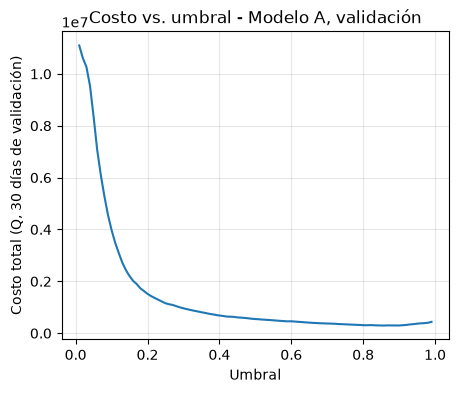

Umbral elegido en validación: 0.9
Costo en validación: Q 297,300
Precisión: 0.597
Recall: 0.755
F1: 0.667


In [7]:
COSTO_FRAUDE_NO_DETECTADO = 4200
COSTO_BLOQUEO_LEGITIMO = 180


def costo_total(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    costo = (
        fn * COSTO_FRAUDE_NO_DETECTADO
        + fp * COSTO_BLOQUEO_LEGITIMO
    )
    return costo, fp, fn, tp, tn


umbrales = np.linspace(0.01, 0.99, 99)
resultados = []
for umbral in umbrales:
    pred_val = (puntaje_val >= umbral).astype(int)
    costo, fp, fn, tp, tn = costo_total(yval, pred_val)
    resultados.append((umbral, costo, fp, fn, tp, tn))

res_df = pd.DataFrame(
    resultados,
    columns=["umbral", "costo_total_val", "fp", "fn", "tp", "tn"],
)

plt.figure(figsize=(5, 4))
plt.plot(res_df.umbral, res_df.costo_total_val)
plt.xlabel("Umbral")
plt.ylabel("Costo total (Q, 30 días de validación)")
plt.title("Costo vs. umbral - Modelo A, validación")
plt.grid(alpha=0.3)
plt.show()

mejor = res_df.loc[res_df.costo_total_val.idxmin()]
umbral_a = float(mejor.umbral)
pred_val_final = (puntaje_val >= umbral_a).astype(int)

print("Umbral elegido en validación:", round(umbral_a, 2))
print("Costo en validación: Q {:,.0f}".format(mejor.costo_total_val))
print("Precisión:", round(precision_score(yval, pred_val_final), 3))
print("Recall:", round(recall_score(yval, pred_val_final), 3))
print("F1:", round(f1_score(yval, pred_val_final), 3))

## 6. Contrato de la secuencia (declarado antes de programar B)

Antes de escribir una sola linea de codigo del modelo secuencial, fijamos por escrito
las decisiones que pide el protocolo. No se modifican despues de ver resultados de
validacion; solo los **hiperparametros de entrenamiento** (tasa de aprendizaje, tamano
oculto, regularizacion, numero de epocas) se ajustan con validacion, como permite la
seccion 2.

**Transaccion objetivo y horizonte de prediccion.** Para cada transaccion actual `t` de
un cliente, el modelo predice si `t` es fraudulenta (`label` de `t`). No se predice
ningun evento futuro; el horizonte es la propia transaccion.

**Longitud maxima `k = 20`.** El episodio mas largo que inyecta el generador es
`rafaga` (8-12 eventos) y `escalada` (hasta 6 eventos); una ventana de 20 transacciones
cubre ambos con margen, sin crecer tanto que la mayoria de los clientes (con pocas
transacciones por dia) terminen dominados por relleno.

**Padding.** No se rellena con ceros de forma ingenua. Cada secuencia usa su longitud
real `min(k, transacciones previas del cliente + 1)` y se procesa con
`pack_padded_sequence` de PyTorch: el GRU nunca recorre pasos de relleno, asi que no
puede aprender nada de un "evento fantasma".

**Variables por evento**, calculadas causalmente (solo con lo ocurrido hasta ese evento
incluido):

- `log1p(amount)`, normalizado con media/desviacion de train.
- `log1p(tiempo en horas desde la transaccion anterior del mismo cliente)`, normalizado
  con train (0 si es la primera transaccion observada del cliente). Es la variable de
  **velocidad**: sin ella el modelo no tiene forma de distinguir eventos separados por
  segundos de eventos separados por dias.
- hora del dia codificada como seno/coseno.
- dia de la semana codificado como seno/coseno.
- identidad de comercio y canal, como **embeddings aprendidos** (no como variables fijas
  de frecuencia).

Deliberadamente el Modelo B **no** recibe ninguna de las variables agregadas de A
(`monto_prom_24h`, `n_trans_ultima_hora`, `monto_max_dia`, `diversidad_comercios_7d`,
frecuencias de comercio/canal). La pregunta que B debe responder es si el orden crudo,
sin agregados, ya aporta señal. La Apuesta C combinara ambas fuentes.

**Historial que cruza limites temporales.** La ventana de un ejemplo de validacion
puede incluir transacciones de train del mismo cliente (ya ocurrieron). Un ejemplo de
train, por construccion, solo puede ver otras transacciones de train, porque su
historial es necesariamente anterior. Ningun ejemplo ve una transaccion posterior a su
propio `timestamp`. No se construye ninguna secuencia de test todavia.

**Etiquetado de `escalada`.** Se mantiene la decision ya congelada por Persona 1: todas
las transacciones del episodio, incluidas las compras pequeñas, tienen `label = 1`.

**Arquitectura candidata y criterio de seleccion.** Un GRU de una sola capa (menos
parametros que un LSTM, entrena mas rapido en CPU y es razonable a esta escala de
datos) seguido de una cabeza MLP pequeña. Hiperparametros (tamaño oculto, dropout, tasa
de aprendizaje, peso de clase, numero de epocas) se seleccionan por **AUC-PR en
validacion**, con paro anticipado (`patience`) para evitar sobreajuste. Test no se toca
en ningun momento de esta seccion.

### 6.1 Construccion causal de las secuencias

`generador.py` ya entrega `seq_index` (posicion del cliente dentro de su propia
secuencia cronologica) y el `df` esta ordenado por `client_id` y `timestamp`. Eso
permite construir cada ventana de historial con un simple *slice* de arreglo: no hace
falta ningun bucle por cliente ni ninguna operacion de `groupby` adicional, y el
resultado es exactamente causal por construccion (`start = i - length + 1`, donde
`length = min(k, seq_index[i] + 1)`).

In [8]:
K = 20  # longitud maxima de la secuencia, fijada en la seccion 6

ts_arr = df["timestamp"].to_numpy(dtype=np.float64)
seq_idx_arr = df["seq_index"].to_numpy(dtype=np.int64)

# tiempo (en horas) desde la transaccion anterior del mismo cliente; 0 si es la primera
tiene_prev = seq_idx_arr > 0
dt_prev = np.zeros(len(df), dtype=np.float64)
dt_prev[tiene_prev] = ts_arr[tiene_prev] - ts_arr[np.where(tiene_prev)[0] - 1]
log_dt = np.log1p(np.clip(dt_prev, 0, None))

train_mask_arr = (df["split"] == "train").to_numpy()
mu_amt_b = np.log1p(df.loc[train_mask_arr, "amount"]).mean()
sd_amt_b = np.log1p(df.loc[train_mask_arr, "amount"]).std()
mu_dt_b = log_dt[train_mask_arr].mean()
sd_dt_b = log_dt[train_mask_arr].std()

log_amt_b = (np.log1p(df["amount"].to_numpy(dtype=np.float64)) - mu_amt_b) / sd_amt_b
log_dt_b = (log_dt - mu_dt_b) / sd_dt_b
hora_arr = df["hora_del_dia"].to_numpy(dtype=np.float64)
hora_sin = np.sin(2 * np.pi * hora_arr / 24.0)
hora_cos = np.cos(2 * np.pi * hora_arr / 24.0)
dow_arr = df["dia_semana"].to_numpy(dtype=np.float64)
dow_sin = np.sin(2 * np.pi * dow_arr / 7.0)
dow_cos = np.cos(2 * np.pi * dow_arr / 7.0)

# variables continuas por evento, en el orden declarado en la seccion 6
EVENT_COLS = ["log_amount", "log_dt_prev", "hora_sin", "hora_cos", "dow_sin", "dow_cos"]
cont_feats = np.stack([log_amt_b, log_dt_b, hora_sin, hora_cos, dow_sin, dow_cos], axis=1).astype(np.float32)
merchant_idx_arr = df["merchant"].to_numpy(dtype=np.int64)
channel_idx_arr = df["channel"].to_numpy(dtype=np.int64)
labels_arr = df["label"].to_numpy(dtype=np.float32)

lengths_all = np.minimum(K, seq_idx_arr + 1)
starts_all = np.arange(len(df)) - lengths_all + 1

train_idx_seq = np.where(train_mask_arr)[0]
val_idx_seq = np.where((df["split"] == "val").to_numpy())[0]

print("Variables por evento:", EVENT_COLS)
print("Secuencias de train:", len(train_idx_seq), " Secuencias de validacion:", len(val_idx_seq))
print("Longitud de secuencia (train): min", lengths_all[train_idx_seq].min(),
      "media", round(lengths_all[train_idx_seq].mean(), 2),
      "max", lengths_all[train_idx_seq].max())

Variables por evento: ['log_amount', 'log_dt_prev', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos']
Secuencias de train: 271752  Secuencias de validacion: 67632
Longitud de secuencia (train): min 1 media 17.91 max 20


## 7. Modelo B - modelo secuencial (GRU)

**Bitacora de ajuste en validacion (documentada para que quede constancia del proceso,
no solo del resultado final):**

- Con `pos_weight = n_neg / n_pos` (~332, el desbalance real de train) el modelo se
  sobreajustaba de inmediato: el mejor AUC-PR de validacion aparecia en la epoca 3
  (≈0.21) y luego caia sostenidamente.
- Bajar el peso de clase a `sqrt(n_neg / n_pos)` mas `dropout=0.3` y `weight_decay=1e-4`
  estabilizo el entrenamiento (mejor AUC-PR ≈0.38 hacia la epoca 16), pero seguia muy
  por debajo del 0.7368 de A.
- La variable que faltaba era `log1p(tiempo desde la transaccion anterior)`: sin ella el
  GRU no tiene ninguna señal directa de velocidad entre eventos, que es precisamente el
  mecanismo de `rafaga` y parte de `escalada`. Al agregarla, el AUC-PR de validacion
  paso de ≈0.47 en la primera epoca a su mejor valor en unas pocas epocas mas.

Arquitectura final: `GRU(hidden=48)` sobre las variables continuas (seccion 6.1) mas
embeddings de comercio (dim 8) y canal (dim 4), seguido de una cabeza
`Linear(48→16) → ReLU → Linear(16→1)`. Entrenamiento con `AdamW`, `ReduceLROnPlateau`
sobre el AUC-PR de validacion, y paro anticipado (`patience=8` epocas sin mejora). El
umbral, el numero de epocas y estos hiperparametros se fijaron enteramente con
validacion; test no se ha tocado.

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

N_MERCHANTS_B = len(generador.MERCHANT_CATEGORIES)
N_CHANNELS_B = len(generador.CHANNELS)
N_CONT_B = cont_feats.shape[1]


class SecuenciaDataset(Dataset):
    """Cada ejemplo es la ventana causal (hasta k eventos) que termina en la
    transaccion objetivo. `agg_idx`, si se da, agrega las variables agregadas de A
    (usadas solo por la Apuesta C)."""

    def __init__(self, target_idx, agg_feats=None):
        self.target_idx = target_idx
        self.agg_feats = agg_feats

    def __len__(self):
        return len(self.target_idx)

    def __getitem__(self, j):
        i = self.target_idx[j]
        s, L = starts_all[i], lengths_all[i]
        cont = cont_feats[s:i + 1]
        merch = merchant_idx_arr[s:i + 1]
        chan = channel_idx_arr[s:i + 1]
        agg = self.agg_feats[i] if self.agg_feats is not None else None
        return cont, merch, chan, L, labels_arr[i], agg


def collate_secuencias(batch):
    conts, merchs, chans, lens, ys, aggs = zip(*batch)
    lens = np.array(lens)
    maxlen = lens.max()
    B = len(batch)
    cont_p = np.zeros((B, maxlen, N_CONT_B), dtype=np.float32)
    merch_p = np.zeros((B, maxlen), dtype=np.int64)
    chan_p = np.zeros((B, maxlen), dtype=np.int64)
    for b in range(B):
        L = lens[b]
        cont_p[b, :L] = conts[b]
        merch_p[b, :L] = merchs[b]
        chan_p[b, :L] = chans[b]
    out = [torch.from_numpy(cont_p), torch.from_numpy(merch_p), torch.from_numpy(chan_p),
           torch.from_numpy(lens), torch.tensor(ys, dtype=torch.float32)]
    if aggs[0] is not None:
        out.append(torch.tensor(np.stack(aggs), dtype=torch.float32))
    else:
        out.append(None)
    return tuple(out)


class ModeloSecuencial(nn.Module):
    """GRU sobre la secuencia de eventos. Si `agg_dim > 0`, concatena variables
    agregadas causales (Apuesta C) con el estado final del GRU antes de la cabeza."""

    def __init__(self, hidden=48, merch_dim=8, chan_dim=4, dropout=0.3, agg_dim=0):
        super().__init__()
        self.merch_emb = nn.Embedding(N_MERCHANTS_B, merch_dim)
        self.chan_emb = nn.Embedding(N_CHANNELS_B, chan_dim)
        in_dim = N_CONT_B + merch_dim + chan_dim
        self.gru = nn.GRU(in_dim, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.agg_dim = agg_dim
        self.head = nn.Sequential(
            nn.Linear(hidden + agg_dim, 16), nn.ReLU(), nn.Linear(16, 1)
        )

    def forward(self, cont, merch, chan, lens, agg=None):
        x = torch.cat([cont, self.merch_emb(merch), self.chan_emb(chan)], dim=-1)
        packed = nn.utils.rnn.pack_padded_sequence(x, lens.cpu(), batch_first=True, enforce_sorted=False)
        _, h = self.gru(packed)
        z = self.drop(h[-1])
        if self.agg_dim > 0:
            z = torch.cat([z, agg], dim=-1)
        return self.head(z).squeeze(-1)


def puntuar(model, dl):
    model.eval()
    scores = []
    with torch.no_grad():
        for cont, merch, chan, lens, y, agg in dl:
            out = model(cont, merch, chan, lens, agg)
            scores.append(torch.sigmoid(out).numpy())
    return np.concatenate(scores)


def entrenar_modelo_secuencial(model, dl_train, dl_val, y_val_idx, max_epochs=30,
                                lr=5e-4, weight_decay=1e-4, patience=8, seed=2027,
                                tag="modelo"):
    torch.manual_seed(seed)
    n_pos = labels_arr[train_idx_seq].sum()
    n_neg = len(train_idx_seq) - n_pos
    pos_weight = torch.tensor((n_neg / n_pos) ** 0.5, dtype=torch.float32)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)

    best_ap, best_epoch, best_state, patience_left = -1.0, -1, None, patience
    historial = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        for cont, merch, chan, lens, y, agg in dl_train:
            opt.zero_grad()
            loss = loss_fn(model(cont, merch, chan, lens, agg), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        scores = puntuar(model, dl_val)
        ap = average_precision_score(labels_arr[y_val_idx], scores)
        sched.step(ap)
        historial.append((epoch, ap))
        if ap > best_ap:
            best_ap, best_epoch = ap, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
        print(f"[{tag}] epoca {epoch} AUC-PR val {ap:.4f} (mejor {best_ap:.4f}@{best_epoch})")
        if patience_left <= 0:
            print(f"[{tag}] paro anticipado")
            break

    model.load_state_dict(best_state)
    return model, best_ap, best_epoch, historial


ds_train_b = SecuenciaDataset(train_idx_seq)
ds_val_b = SecuenciaDataset(val_idx_seq)
dl_train_b = DataLoader(ds_train_b, batch_size=1024, shuffle=True, collate_fn=collate_secuencias)
dl_val_b = DataLoader(ds_val_b, batch_size=2048, shuffle=False, collate_fn=collate_secuencias)

modelo_b = ModeloSecuencial(hidden=48, dropout=0.3, agg_dim=0)
modelo_b, ap_b_val, epoca_b, hist_b = entrenar_modelo_secuencial(
    modelo_b, dl_train_b, dl_val_b, val_idx_seq, tag="B"
)

puntaje_val_b = puntuar(modelo_b, dl_val_b)
print()
print("Modelo B - AUC-PR (validacion):", round(ap_b_val, 4), " (Modelo A:", round(average_precision_score(yval, puntaje_val), 4), ")")

[B] epoca 1 AUC-PR val 0.4689 (mejor 0.4689@1)


[B] epoca 2 AUC-PR val 0.6900 (mejor 0.6900@2)


[B] epoca 3 AUC-PR val 0.7429 (mejor 0.7429@3)


[B] epoca 4 AUC-PR val 0.7364 (mejor 0.7429@3)


[B] epoca 5 AUC-PR val 0.7484 (mejor 0.7484@5)


...

[B] epoca 15 AUC-PR val 0.7508 (mejor 0.7584@10)


[B] epoca 16 AUC-PR val 0.7508 (mejor 0.7584@10)


[B] epoca 17 AUC-PR val 0.7552 (mejor 0.7584@10)


[B] epoca 18 AUC-PR val 0.7572 (mejor 0.7584@10)
[B] paro anticipado



Modelo B - AUC-PR (validacion): 0.7584  (Modelo A: 0.7281 )


### 7.1 Desempeño de B por mecanismo, calculado en validacion

Misma metodologia que se uso para A: cada mecanismo se compara contra el mismo
conjunto de transacciones legitimas de validacion.

In [10]:
df_val["puntaje_b"] = puntaje_val_b

filas_b = []
for tipo in ["escalada", "rafaga", "comercio_atipico"]:
    mask = (df_val.fraud_type == tipo) | (df_val.label == 0)
    sub = df_val.loc[mask]
    if sub.label.sum() > 0:
        filas_b.append({
            "fraud_type": tipo,
            "n_positivos_val": int(sub.label.sum()),
            "AUC-PR_Modelo_A_val": average_precision_score(sub.label, sub.puntaje_a),
            "AUC-PR_Modelo_B_val": average_precision_score(sub.label, sub.puntaje_b),
        })

resumen_tipo_val_ab = pd.DataFrame(filas_b)
resumen_tipo_val_ab["diferencia_B_menos_A"] = (
    resumen_tipo_val_ab["AUC-PR_Modelo_B_val"] - resumen_tipo_val_ab["AUC-PR_Modelo_A_val"]
)
resumen_tipo_val_ab

,fraud_type,n_positivos_val,AUC-PR_Modelo_A_val,AUC-PR_Modelo_B_val,diferencia_B_menos_A
0,escalada,130,0.657383,0.752063,0.094680
1,rafaga,126,0.722595,0.749926,0.027331
2,comercio_atipico,9,0.015441,0.000348,-0.015093


## 8. Analisis economico de B en validacion

Se reutiliza exactamente `costo_total()` de la seccion 5, con los mismos costos
definidos por el comite (Q4,200 por fraude no detectado, Q180 por bloqueo legitimo). El
umbral de B se elige unicamente con validacion, igual que se hizo con A.

In [11]:
umbrales_b = np.linspace(0.01, 0.99, 99)
resultados_b = []
for umbral in umbrales_b:
    pred = (puntaje_val_b >= umbral).astype(int)
    costo, fp, fn, tp, tn = costo_total(yval, pred)
    resultados_b.append((umbral, costo, fp, fn, tp, tn))

res_df_b = pd.DataFrame(resultados_b, columns=["umbral", "costo_total_val", "fp", "fn", "tp", "tn"])
mejor_b = res_df_b.loc[res_df_b.costo_total_val.idxmin()]
umbral_b = float(mejor_b.umbral)
pred_val_b_final = (puntaje_val_b >= umbral_b).astype(int)

print("Umbral elegido en validacion (B):", round(umbral_b, 2))
print("Costo en validacion (B): Q {:,.0f}".format(mejor_b.costo_total_val))
print("Costo en validacion (A): Q {:,.0f}".format(mejor.costo_total_val))
print("Precision:", round(precision_score(yval, pred_val_b_final), 3))
print("Recall:", round(recall_score(yval, pred_val_b_final), 3))
print("F1:", round(f1_score(yval, pred_val_b_final), 3))

Umbral elegido en validacion (B): 0.46
Costo en validacion (B): Q 279,300
Costo en validacion (A): Q 297,300
Precision: 0.659
Recall: 0.766
F1: 0.709


## 9. Apuesta C - hipotesis declarada antes de entrenar

**Hipotesis:** un modelo hibrido que combine el estado final del GRU de B (memoria de
la secuencia cruda) con las variables agregadas causales de A (frecuencia global del
comercio, diversidad de comercios en 7 dias, promedio de 24h, maximo del dia) mejorara
sobre ambos por separado, porque cada fuente aporta señal que la otra no tiene: B ve el
orden pero pierde estadisticas de largo plazo cuando el cliente tiene mas de `k=20`
transacciones en su historial reciente; A ve esas estadisticas pero no el orden.

**Criterio de exito, fijado ahora, antes de entrenar C, y que no se modificara despues
de observar su resultado:** consideraremos util a C si, en validacion,

1. mejora el AUC-PR en al menos **0.02** frente al mejor entre A y B, y
2. reduce el costo economico en al menos **5%** frente al mejor entre A y B.

Si no cumple ambas condiciones, C se reporta como intento fallido (una apuesta que no
funciono), no se le baja el criterio para que "parezca exitosa".

In [12]:
AGG_COLS_C = ["monto_prom_24h", "n_trans_ultima_hora", "monto_max_dia",
              "diversidad_comercios_7d", "merchant_freq", "channel_freq"]

log_cols = ["monto_prom_24h", "n_trans_ultima_hora", "monto_max_dia", "diversidad_comercios_7d"]
agg_raw = df[AGG_COLS_C].to_numpy(dtype=np.float64).copy()
for j, col in enumerate(AGG_COLS_C):
    if col in log_cols:
        agg_raw[:, j] = np.log1p(np.clip(agg_raw[:, j], 0, None))
mu_agg = agg_raw[train_mask_arr].mean(axis=0)
sd_agg = agg_raw[train_mask_arr].std(axis=0)
sd_agg[sd_agg == 0] = 1.0
agg_feats_c = ((agg_raw - mu_agg) / sd_agg).astype(np.float32)

ds_train_c = SecuenciaDataset(train_idx_seq, agg_feats=agg_feats_c)
ds_val_c = SecuenciaDataset(val_idx_seq, agg_feats=agg_feats_c)
dl_train_c = DataLoader(ds_train_c, batch_size=1024, shuffle=True, collate_fn=collate_secuencias)
dl_val_c = DataLoader(ds_val_c, batch_size=2048, shuffle=False, collate_fn=collate_secuencias)

modelo_c = ModeloSecuencial(hidden=48, dropout=0.3, agg_dim=len(AGG_COLS_C))
modelo_c, ap_c_val, epoca_c, hist_c = entrenar_modelo_secuencial(
    modelo_c, dl_train_c, dl_val_c, val_idx_seq, tag="C"
)

puntaje_val_c = puntuar(modelo_c, dl_val_c)
print()
print("Modelo C - AUC-PR (validacion):", round(ap_c_val, 4))
print("Modelo B - AUC-PR (validacion):", round(ap_b_val, 4))
print("Modelo A - AUC-PR (validacion):", round(average_precision_score(yval, puntaje_val), 4))

[C] epoca 1 AUC-PR val 0.6593 (mejor 0.6593@1)


[C] epoca 2 AUC-PR val 0.6841 (mejor 0.6841@2)


[C] epoca 3 AUC-PR val 0.7013 (mejor 0.7013@3)


[C] epoca 4 AUC-PR val 0.7089 (mejor 0.7089@4)


[C] epoca 5 AUC-PR val 0.7203 (mejor 0.7203@5)


...

[C] epoca 23 AUC-PR val 0.7919 (mejor 0.7971@18)


[C] epoca 24 AUC-PR val 0.7894 (mejor 0.7971@18)


[C] epoca 25 AUC-PR val 0.7924 (mejor 0.7971@18)


[C] epoca 26 AUC-PR val 0.7884 (mejor 0.7971@18)
[C] paro anticipado



Modelo C - AUC-PR (validacion): 0.7971
Modelo B - AUC-PR (validacion): 0.7584
Modelo A - AUC-PR (validacion): 0.7281


### 9.1 Verificacion del criterio de exito de C

In [13]:
df_val["puntaje_c"] = puntaje_val_c

mejor_auc_ab = max(ap_b_val, average_precision_score(yval, puntaje_val))

umbrales_c = np.linspace(0.01, 0.99, 99)
resultados_c = []
for umbral in umbrales_c:
    pred = (puntaje_val_c >= umbral).astype(int)
    costo, fp, fn, tp, tn = costo_total(yval, pred)
    resultados_c.append((umbral, costo, fp, fn, tp, tn))
res_df_c = pd.DataFrame(resultados_c, columns=["umbral", "costo_total_val", "fp", "fn", "tp", "tn"])
mejor_c = res_df_c.loc[res_df_c.costo_total_val.idxmin()]
umbral_c = float(mejor_c.umbral)

mejor_costo_ab = min(mejor_b.costo_total_val, mejor.costo_total_val)

cumple_auc = (ap_c_val - mejor_auc_ab) >= 0.02
cumple_costo = mejor_c.costo_total_val <= mejor_costo_ab * 0.95

print("AUC-PR C:", round(ap_c_val, 4), " | mejor entre A y B:", round(mejor_auc_ab, 4),
      " | mejora:", round(ap_c_val - mejor_auc_ab, 4), " | cumple (+0.02):", cumple_auc)
print("Costo C: Q {:,.0f}".format(mejor_c.costo_total_val),
      " | mejor entre A y B: Q {:,.0f}".format(mejor_costo_ab),
      " | cumple (-5%):", cumple_costo)
print()
if cumple_auc and cumple_costo:
    print("VEREDICTO: la Apuesta C cumple el criterio declarado en la seccion 9. Se adopta como candidata.")
else:
    print("VEREDICTO: la Apuesta C NO cumple el criterio declarado en la seccion 9. Se reporta como intento fallido; no se relaja el criterio a posteriori.")

AUC-PR C: 0.7971  | mejor entre A y B: 0.7584  | mejora: 0.0387  | cumple (+0.02): True
Costo C: Q 246,000  | mejor entre A y B: Q 279,300  | cumple (-5%): True

VEREDICTO: la Apuesta C cumple el criterio declarado en la seccion 9. Se adopta como candidata.


## 10. Prueba obligatoria 1 - Permutacion controlada

Se usa el Modelo B **ya entrenado** (no se reentrena). Se conservan los mismos eventos,
etiquetas y variables agregadas; solo se baraja el orden del historial anterior a la
transaccion objetivo, que permanece fija en la ultima posicion de la secuencia. Se usan
varias semillas fijas y documentadas, y se reporta media y dispersion, tal como pide el
protocolo.

In [14]:
def puntuar_permutado(model, target_idx, seed):
    rng_local = np.random.default_rng(seed)
    scores = np.zeros(len(target_idx), dtype=np.float32)
    model.eval()
    batch_size = 2048
    with torch.no_grad():
        for start in range(0, len(target_idx), batch_size):
            idxs = target_idx[start:start + batch_size]
            lens = lengths_all[idxs]
            maxlen = lens.max()
            B = len(idxs)
            cont_p = np.zeros((B, maxlen, N_CONT_B), dtype=np.float32)
            merch_p = np.zeros((B, maxlen), dtype=np.int64)
            chan_p = np.zeros((B, maxlen), dtype=np.int64)
            for b, i in enumerate(idxs):
                s, L = starts_all[i], lengths_all[i]
                cont = cont_feats[s:i + 1].copy()
                merch = merchant_idx_arr[s:i + 1].copy()
                chan = channel_idx_arr[s:i + 1].copy()
                if L > 1:
                    # la transaccion objetivo queda fija en la ultima posicion;
                    # se baraja unicamente el historial anterior (posiciones 0..L-2)
                    orden = rng_local.permutation(L - 1)
                    cont[:L - 1] = cont[:L - 1][orden]
                    merch[:L - 1] = merch[:L - 1][orden]
                    chan[:L - 1] = chan[:L - 1][orden]
                cont_p[b, :L] = cont
                merch_p[b, :L] = merch
                chan_p[b, :L] = chan
            out = model(torch.from_numpy(cont_p), torch.from_numpy(merch_p),
                        torch.from_numpy(chan_p), torch.from_numpy(lens), None)
            scores[start:start + B] = torch.sigmoid(out).numpy()
    return scores


SEEDS_PERMUTACION = [1, 2, 3, 4, 5]
resultados_permutacion = []
for seed in SEEDS_PERMUTACION:
    scores_perm = puntuar_permutado(modelo_b, val_idx_seq, seed)
    ap_perm = average_precision_score(labels_arr[val_idx_seq], scores_perm)
    resultados_permutacion.append({"seed": seed, "AUC-PR_B_permutado": ap_perm})

res_perm_df = pd.DataFrame(resultados_permutacion)
media_perm = res_perm_df["AUC-PR_B_permutado"].mean()
std_perm = res_perm_df["AUC-PR_B_permutado"].std()

print(res_perm_df)
print()
print(f"AUC-PR B original (validacion): {ap_b_val:.4f}")
print(f"AUC-PR B permutado: media={media_perm:.4f}  desviacion={std_perm:.4f}")
print(f"Caida por permutacion: {ap_b_val - media_perm:.4f}")
if ap_b_val - media_perm > 0.02:
    print("Interpretacion: el desempeño SI cae al perder el orden -> B aprovecha el orden.")
else:
    print("Interpretacion: el desempeño NO cae de forma relevante al perder el orden -> no se puede afirmar que B aproveche el orden.")

# guardamos tambien el puntaje permutado de la primera semilla para el desglose por mecanismo
df_val["puntaje_b_permutado"] = puntuar_permutado(modelo_b, val_idx_seq, SEEDS_PERMUTACION[0])

   seed  AUC-PR_B_permutado
0     1            0.308601
1     2            0.286954
2     3            0.302902
3     4            0.301532
4     5            0.298428

AUC-PR B original (validacion): 0.7584
AUC-PR B permutado: media=0.2997  desviacion=0.0080
Caida por permutacion: 0.4587
Interpretacion: el desempeño SI cae al perder el orden -> B aprovecha el orden.


## 11. Prueba obligatoria 2 - Evaluacion por mecanismo

Tabla combinada por mecanismo: numero de positivos, AUC-PR de A y B, recall de B en su
umbral economico global (`umbral_b`, seccion 8), diferencia B - A, y diferencia entre B
original y B permutado (con la primera semilla de la seccion 10).

In [15]:
filas_prueba2 = []
for tipo in ["escalada", "rafaga", "comercio_atipico"]:
    mask = (df_val.fraud_type == tipo) | (df_val.label == 0)
    sub = df_val.loc[mask]
    if sub.label.sum() == 0:
        continue
    pred_b_tipo = (sub.puntaje_b >= umbral_b).astype(int)
    filas_prueba2.append({
        "fraud_type": tipo,
        "n_positivos_val": int(sub.label.sum()),
        "AUC-PR_A": average_precision_score(sub.label, sub.puntaje_a),
        "AUC-PR_B": average_precision_score(sub.label, sub.puntaje_b),
        "recall_B_en_umbral": recall_score(sub.label, pred_b_tipo),
        "diferencia_B_menos_A": (
            average_precision_score(sub.label, sub.puntaje_b)
            - average_precision_score(sub.label, sub.puntaje_a)
        ),
        "AUC-PR_B_permutado": average_precision_score(sub.label, sub.puntaje_b_permutado),
        "diferencia_original_menos_permutado": (
            average_precision_score(sub.label, sub.puntaje_b)
            - average_precision_score(sub.label, sub.puntaje_b_permutado)
        ),
    })

resumen_prueba2 = pd.DataFrame(filas_prueba2)
resumen_prueba2

,fraud_type,n_positivos_val,AUC-PR_A,AUC-PR_B,recall_B_en_umbral,diferencia_B_menos_A,AUC-PR_B_permutado,diferencia_original_menos_permutado
0,escalada,130,0.657383,0.752063,0.800000,0.094680,0.294286,0.457777
1,rafaga,126,0.722595,0.749926,0.785714,0.027331,0.171153,0.578772
2,comercio_atipico,9,0.015441,0.000348,0.000000,-0.015093,0.000439,-0.000092


## 12. Resumen comparativo en validacion (A, B, C)

Ultima tabla antes de congelar el protocolo. Todo lo que contiene proviene unicamente
de validacion.

In [16]:
pred_val_c_final = (puntaje_val_c >= umbral_c).astype(int)

resumen_final = pd.DataFrame([
    {
        "modelo": "A (arboles, sin orden)",
        "AUC-PR_val": average_precision_score(yval, puntaje_val),
        "umbral": umbral_a,
        "precision": precision_score(yval, pred_val_final),
        "recall": recall_score(yval, pred_val_final),
        "f1": f1_score(yval, pred_val_final),
        "costo_val_Q": mejor.costo_total_val,
    },
    {
        "modelo": "B (GRU secuencial)",
        "AUC-PR_val": ap_b_val,
        "umbral": umbral_b,
        "precision": precision_score(yval, pred_val_b_final),
        "recall": recall_score(yval, pred_val_b_final),
        "f1": f1_score(yval, pred_val_b_final),
        "costo_val_Q": mejor_b.costo_total_val,
    },
    {
        "modelo": "C (GRU + agregados)",
        "AUC-PR_val": ap_c_val,
        "umbral": umbral_c,
        "precision": precision_score(yval, pred_val_c_final),
        "recall": recall_score(yval, pred_val_c_final),
        "f1": f1_score(yval, pred_val_c_final),
        "costo_val_Q": mejor_c.costo_total_val,
    },
])
resumen_final

,modelo,AUC-PR_val,umbral,precision,recall,f1,costo_val_Q
0,"A (arboles, sin orden)",0.728134,0.90,0.597015,0.754717,0.666667,297300.0
1,B (GRU secuencial),0.758368,0.46,0.659091,0.766038,0.708551,279300.0
2,C (GRU + agregados),0.797061,0.33,0.393939,0.833962,0.535109,246000.0


## 13. Evaluacion final en test - NO EJECUTAR TODAVIA

Antes de correr esta seccion, el equipo debe revisar en conjunto y congelar por
escrito:

- Modelo A (Persona 1) — congelado.
- Modelo B (seccion 7) — congelado con los hiperparametros de esta version.
- Apuesta C (seccion 9) y su veredicto respecto al criterio declarado — congelado.
- Permutacion controlada (seccion 10) y evaluacion por mecanismo (seccion 11) —
  congeladas.
- Umbrales economicos `umbral_a`, `umbral_b`, `umbral_c`, elegidos unicamente con
  validacion.

Cuando ambos integrantes confirmen el congelamiento, esta seccion (y no antes) debera:

1. Crear `yte` por primera vez en todo el notebook.
2. Construir las secuencias de test reutilizando `starts_all`/`lengths_all` (que ya son
   causalmente validas para test, porque el historial de un ejemplo de test puede
   incluir train y validacion, tal como fija la seccion 6).
3. Generar los puntajes de A, B y C sobre exactamente las mismas transacciones de test.
4. Repetir la permutacion controlada sobre test como confirmacion final.
5. Reportar AUC-PR, precision, recall, F1 y costo economico de los tres modelos, elegir
   el candidato final y redactar la recomendacion al comite de riesgos.

Hasta que eso ocurra, no se crea `yte`, no se generan puntajes sobre `Xte` y no se
calcula ninguna metrica, grafica o costo de test.